In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
ScalarFormatter().set_scientific(False)
font = 'NanumSquareRound, AppleGothic, Malgun Gothic, DejaVu Sans'
plt.style.use('bmh')
plt.rcParams['font.family'] = font
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['lines.antialiased'] = True
plt.rcParams['figure.figsize'] = [10.0, 5.0]
plt.rcParams['savefig.dpi'] = 96
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 'medium'
plt.rcParams['figure.titlesize'] = 'medium'

In [3]:
def str_to_list(s):
    if type(s) == list:
        cds = s
    else:
        cds = []
        cds.append(s)
    return cds

In [4]:
def draw_chart(df, left, right=None, log=False):
    left = str_to_list(left)
    fig, ax1 = plt.subplots()
    x = df.index
    i = 1
    for c in left:
        ax1.plot(x, df[c], label=c, color='C'+str(i), alpha=1)
        i += 1
    if log:
        ax1.set_yscale('log')
        ax1.yaxis.set_major_formatter(ScalarFormatter())
        ax1.yaxis.set_minor_formatter(ScalarFormatter())
    # secondary y
    if right is not None:
        right = str_to_list(right)
        ax2 = ax1.twinx()
        i = 6
        for c in right:
            ax2.plot(x, df[c], label=c+'(R)', color='C'+str(i), alpha=0.7)
            ax1.plot(np.nan, label=c+'(R)', color='C'+str(i))
            i += 1
        ax2.grid(False)
        if log:
            ax2.set_yscale('log')
            ax2.yaxis.set_major_formatter(ScalarFormatter())
            ax2.yaxis.set_minor_formatter(ScalarFormatter())
    ax1.legend(loc=0)

In [ ]:
def set_period(start_term, end_term):
    term = pd.period_range(start=start_term, end=end_term, freq='3M')
    release_date = (term.end_time + pd.DateOffset(months=2)).date
    return term, release_date

In [ ]:
start_term = '2005-01-01'
end_term = '2020-12-31'
symbol = 'XRX'
term, release_date = set_period(start_term, end_term)

In [ ]:
acct_is_ttm = {
    'revenue': ['Revenue', 'ISQ'],
    'operating_income': ['Operating Income', 'ISQ'],
    'net_income': ['Net Income', 'ISQ'],
    'EPS': ['EPS - Earnings Per Share', 'ISQ'],
}

In [ ]:
def fn_quarterly(symbol, acct):
    query = 'SELECT term, '
    for k, v in acct.items():
        query += 'MAX(CASE WHEN title="{}" THEN vlu END) AS {}, '.format(v[0], k)
    query = query[:-2]    
    query += ' FROM _fn_stmt '
    query += 'WHERE issue_code="{}" '.format(symbol)
    query += 'GROUP BY term'
    df = db.query_df(query)
    return df

In [ ]:
is_qtr = fn_quarterly(symbol, acct_is_ttm)
is_qtr.term = pd.to_datetime(is_qtr.term)
is_qtr.set_index('term', inplace=True)
# is_qtr.astype(float)
is_qtr.apply(pd.to_numeric, errors='coerce', downcast='float')    
is_qtr.tail()

,revenue,operating_income,net_income,EPS
term,,,,
2019-06-30,2263.0,276.0,178.0,0.77
2019-09-30,2200.0,263.0,221.0,0.96
2019-12-31,2423.0,402.0,821.0,3.52
2020-03-31,1860.0,70.0,-2.0,-0.03
2020-06-30,1465.0,55.0,24.0,0.11


In [ ]:
is_ttm = is_qtr.rolling(4).sum()

In [ ]:
acct_is = {
    'shares': ['Basic Shares Outstanding', 'ISQ'],
}

In [ ]:
is_qtr = fn_quarterly(symbol, acct_is)
is_qtr.term = pd.to_datetime(is_qtr.term)
is_qtr.set_index('term', inplace=True)
# is_qtr.astype(float)
is_qtr.apply(pd.to_numeric, errors='coerce', downcast='float')    
is_qtr.tail()

,shares
term,
2019-06-30,223.606003
2019-09-30,220.268997
2019-12-31,221.968994
2020-03-31,212.750000
2020-06-30,212.949005


In [ ]:
acct_bs = {
    'total_asset': ['Total Assets', 'BSQ'],
    'totla_current_asset': ['Total Current Assets', 'BSQ'],
    'total_LT_asset': ['Total Long-Term Assets', 'BSQ'],
    'total_liabilities': ['Total Liabilities', 'BSQ'],
    'total_current_liabilities': ['Total Current Liabilities', 'BSQ'],
    'LT_debt': ['Long Term Debt', 'BSQ'],
    'shareholder_equity': ['Share Holder Equity', 'BSQ'],
}

In [ ]:
bs = fn_quarterly(symbol, acct_bs)
bs.term = pd.to_datetime(bs.term)
bs.set_index('term', inplace=True)
# bs.astype(float)
bs.apply(pd.to_numeric, errors='coerce', downcast='float')    
bs.tail()

,total_asset,totla_current_asset,total_LT_asset,total_liabilities,total_current_liabilities,LT_debt,shareholder_equity
term,,,,,,,
2019-06-30,14684.0,4237.0,10447.0,9478.0,3176.0,3962.0,5206.0
2019-09-30,14660.0,4340.0,10320.0,9560.0,3923.0,3230.0,5100.0
2019-12-31,15047.0,6140.0,8907.0,9239.0,3435.0,3233.0,5808.0
2020-03-31,14784.0,5977.0,8807.0,9170.0,3373.0,3238.0,5614.0
2020-06-30,14125.0,5391.0,8734.0,8430.0,3791.0,2185.0,5695.0


In [ ]:
acct_cf = {
    'CFO': ['Cash Flow From Operating Activities', 'CFQ'],
    'CFI': ['Cash Flow From Investing Activities', 'CFQ'],
    'CFF': ['Cash Flow From Financial Activities', 'CFQ'],
    'net_cash_flow': ['Net Cash Flow', 'CFQ'],
    'dividend': ['Common Stock Dividends Paid', 'CFQ'],
}

In [ ]:
cf = fn_quarterly(symbol, acct_cf)
cf.term = pd.to_datetime(cf.term)
cf.set_index('term', inplace=True)
# cf.astype(float)
cf.apply(pd.to_numeric, errors='coerce', downcast='float')    
cf.tail(3)

,CFO,CFI,CFF,net_cash_flow,dividend
term,,,,,
2019-12-31,438.0,2216.0,-851.0,1816.0,-60.0
2020-03-31,173.0,-214.0,-60.0,-130.0,-58.0
2020-06-30,-139.0,196.0,-312.0,-221.0,1.0


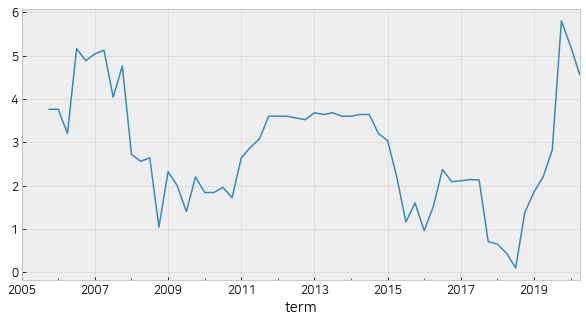

In [ ]:
fn = pd.concat([is_ttm, is_qtr, bs, cf], axis=1)
fn.EPS.plot()

In [ ]:
def price_close_daily_portfolio(cd, start_date, end_date):
    sql = 'SELECT trade_date '
    for c in cd:
        sql += ', max(case when issue_code="{c}" then price_close end) as "{c}" '.format(c=c)
    sql += 'FROM _price_daily_archive '
    sql += 'WHERE  issue_code in ( '
    for c in cd:
        sql += '"{}" '.format(c)
        if c is not cd[-1]:
            sql += ', '
    sql += ') '
    sql += 'AND trade_date >= "{}" '.format(start_date)
    sql += 'AND trade_date <= "{}" '.format(end_date)
    sql += 'GROUP BY trade_date '
    sql += 'ORDER BY trade_date ; '
    rows = db.query_df(sql)
    rows.trade_date = pd.to_datetime(rows.trade_date)
    rows.set_index('trade_date', inplace=True)
    return rows

In [ ]:
price_df = price_close_daily_portfolio([symbol], start_term, end_term)
price_df.rename(columns={symbol:'price'}, inplace=True)
price_df.tail(3)

,price
trade_date,
2020-10-21,19.540001
2020-10-22,19.889999
2020-10-23,19.730000


In [ ]:
df = pd.concat([fn, price_df], axis=1)
df.fillna(method='ffill', inplace=True)
df = df['2006-01-01':]
df.tail(3)

,revenue,operating_income,net_income,EPS,shares,total_asset,totla_current_asset,total_LT_asset,total_liabilities,total_current_liabilities,LT_debt,shareholder_equity,CFO,CFI,CFF,net_cash_flow,dividend,price
2020-10-21,7948.0,790.0,1064.0,4.56,212.949005,14125.0,5391.0,8734.0,8430.0,3791.0,2185.0,5695.0,-139.0,196.0,-312.0,-221.0,1.0,19.540001
2020-10-22,7948.0,790.0,1064.0,4.56,212.949005,14125.0,5391.0,8734.0,8430.0,3791.0,2185.0,5695.0,-139.0,196.0,-312.0,-221.0,1.0,19.889999
2020-10-23,7948.0,790.0,1064.0,4.56,212.949005,14125.0,5391.0,8734.0,8430.0,3791.0,2185.0,5695.0,-139.0,196.0,-312.0,-221.0,1.0,19.730000


In [ ]:
df['PER'] = df['price']/df['EPS']

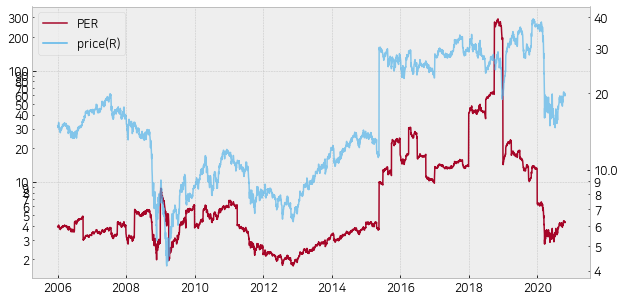

In [ ]:
#df.PER.plot()
draw_chart(df, left='PER', right='price', log=True)

In [ ]:
np.arange(0, 100, 10)

array([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [ ]:
df['per_band_10'] = df['EPS'] * 10
df['per_band_30'] = df['EPS'] * 30
df['per_band_50'] = df['EPS'] * 50

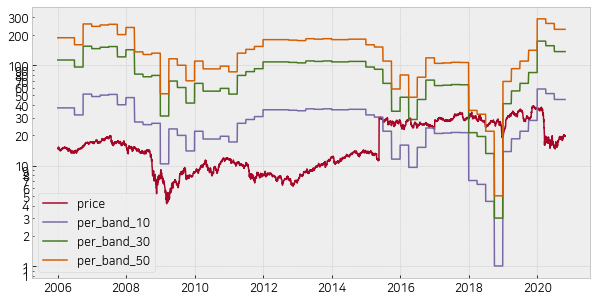

In [ ]:
draw_chart(df, left=['price', 'per_band_10','per_band_30','per_band_50'], log=True)

In [ ]:
df['BPS'] = df['shareholder_equity'] / df['shares']
df['PBR'] = df['price'] / df['BPS']
df['PBR'].tail()

2020-10-19    0.737376
2020-10-20    0.733263
2020-10-21    0.730645
2020-10-22    0.743732
2020-10-23    0.737750
Name: PBR, dtype: float64

In [ ]:
df['pbr_band_1'] = df['BPS'] * 1
df['pbr_band_3'] = df['BPS'] * 3
df['pbr_band_5'] = df['BPS'] * 5

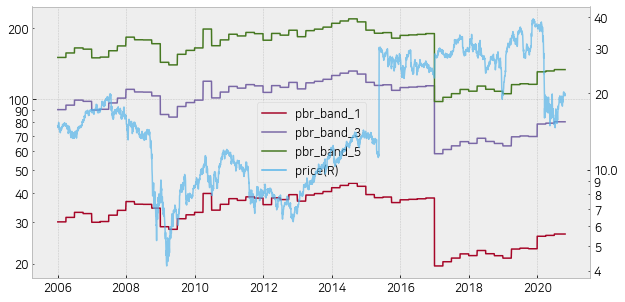

In [ ]:
draw_chart(df, left=['pbr_band_1','pbr_band_3','pbr_band_5'], right='price', log=True)

In [ ]:
df['ROE'] = df['net_income'] / df['shareholder_equity'] * 100

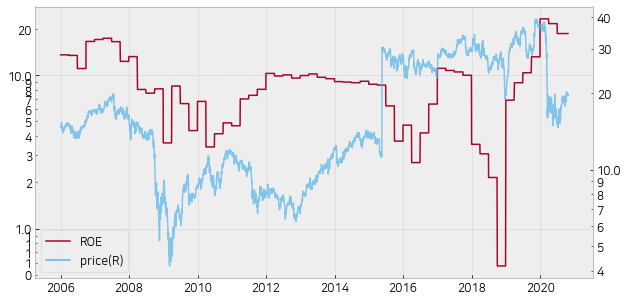

In [ ]:
draw_chart(df, left='ROE', right='price', log=True)

In [ ]:
df['ROA'] = df['operating_income'] / df['total_asset'] * 100

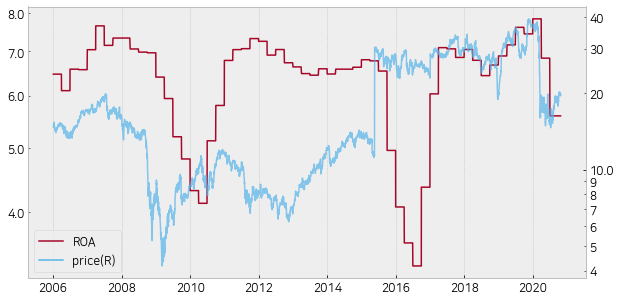

In [ ]:
draw_chart(df, left='ROA', right='price', log=True)

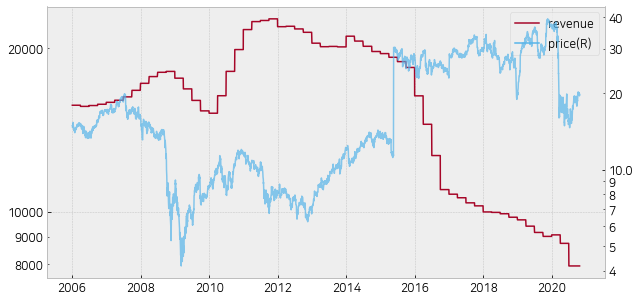

In [ ]:
draw_chart(df, left='revenue', right='price', log=True)

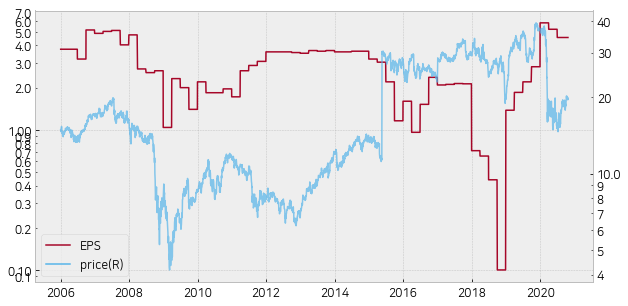

In [ ]:
draw_chart(df, left='EPS', right='price', log=True)

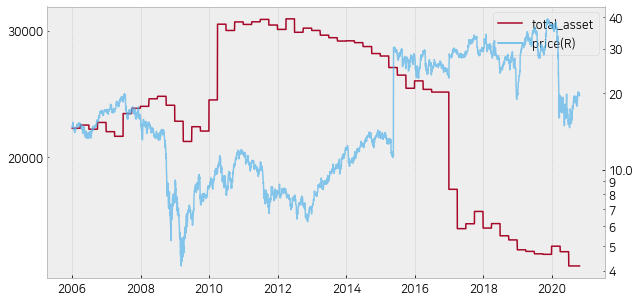

In [ ]:
draw_chart(df, left='total_asset', right='price', log=True)

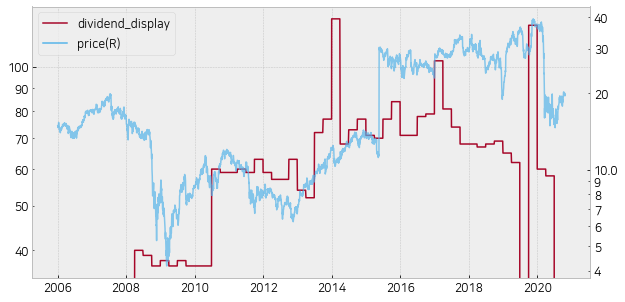

In [ ]:
df['dividend_display'] = df['dividend']*-1
draw_chart(df, left='dividend_display', right='price', log=True)

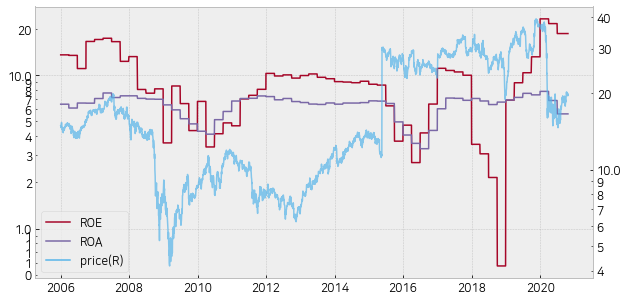

In [ ]:
draw_chart(df, left=['ROE', 'ROA'], right='price', log=True)

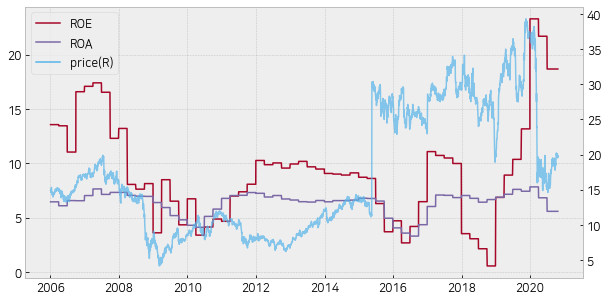

In [ ]:
draw_chart(df, left=['ROE', 'ROA'], right='price', log=False)

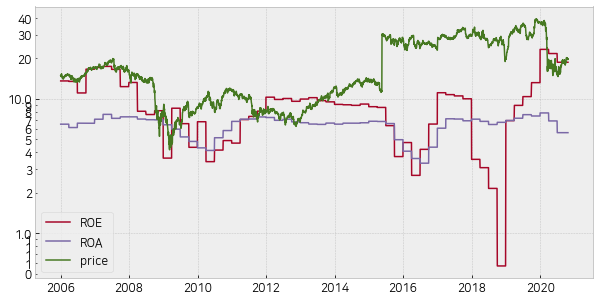

In [ ]:
draw_chart(df, left=['ROE', 'ROA', 'price'], log=True)

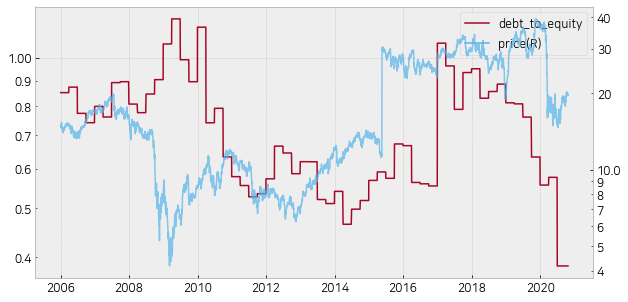

In [ ]:
df['debt_to_equity'] = df['LT_debt'] / df['shareholder_equity']
draw_chart(df, left='debt_to_equity', right='price', log=True)

In [ ]:
df['debt_to_equity']

2006-01-03    0.851693
2006-01-04    0.851693
2006-01-05    0.851693
2006-01-06    0.851693
2006-01-09    0.851693
                ...   
2020-10-19    0.383670
2020-10-20    0.383670
2020-10-21    0.383670
2020-10-22    0.383670
2020-10-23    0.383670
Name: debt_to_equity, Length: 3748, dtype: float64